In [21]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

In [22]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

In [23]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

In [24]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats

score_dict = defaultdict(list)

publisher_society_lookup = {
    "ACS": True,               # American Chemical Society
    "AIP": True,               # American Institute of Physics
    "APS": True,               # American Physical Society
    "Bentham Science": False,  # Commercial publisher
    "Elsevier": False,         # Commercial publisher
    "Frontiers": False,        # Commercial publisher
    "IEEE": True,              # Institute of Electrical and Electronics Engineers
    "IOP": True,               # Institute of Physics
    "MDPI": False,             # Commercial publisher
    "Optica": True,            # Formerly OSA, Optica is a society
    "Pleiades Publishing": False,  # Commercial
    "RSC": True,               # Royal Society of Chemistry
    "Springer Nature": False,  # Commercial
    "Taylor & Francis": False, # Commercial
    "Wiley": False,            # Commercial
    "codata": True,            # Committee on Data of the International Science Council
    "open journals": False     # Generic term, not a society
}

socitey_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():
        score = get_journal_score(journal_results)
        score_list.append(score)  # append the score
        socitey_list.append(publisher_society_lookup[publisher])

# Convert to DataFrame for easier plotting
df = pd.DataFrame({
    'Policy Score': score_list,
    'Society Publisher': socitey_list
})

# Compute means
means = df.groupby('Society Publisher')['Policy Score'].mean()
print("Mean policy scores:")
print(means)

# ANOVA test
society_scores = df[df['Society Publisher'] == True]['Policy Score']
non_society_scores = df[df['Society Publisher'] == False]['Policy Score']

f_val, p_val = stats.f_oneway(society_scores, non_society_scores)
print(f"ANOVA F-statistic: {f_val:.3f}, p-value: {p_val:.3e}")

t_stat_1, p_val_1 = stats.ttest_ind(society_scores, non_society_scores, equal_var=False)
print(f"T-test: {t_stat_1:.3f}, p-value: {p_val_1:.3e}")
            

Mean policy scores:
Society Publisher
False    0.262769
True     0.219924
Name: Policy Score, dtype: float64
ANOVA F-statistic: 9.109, p-value: 2.938e-03
T-test: -3.055, p-value: 2.667e-03


/tmp/ipykernel_12983/1494799528.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_12983/1494799528.py:7: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.violinplot(


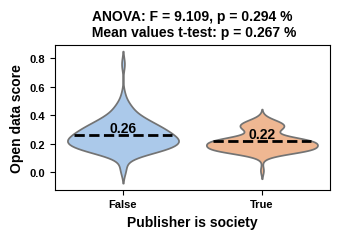

In [25]:
fig = plt.figure(figsize=(3.5, 2.5))

palette = sns.color_palette("pastel")

plt.title(f"ANOVA: F = {f_val:.3f}, p = {p_val*100:.3f} %\n Mean values t-test: p = {p_val_1*100:.3f} %")

sns.violinplot(
    x='Society Publisher',
    y='Policy Score',
    data=df,
    palette=palette,
    inner=None,
    #inner='point'
)

# Add text labels for the means
for i, val in enumerate(means):
    violin_width = 0.8  # default width in sns.violinplot
    plt.hlines(
        y=val,
        xmin=i - violin_width/2 + 0.05,
        xmax=i + violin_width/2 - 0.05,
        colors='black',
        linewidth=2,
        linestyle='--'
    )

    plt.text(
        i,              # x position (0 for False, 1 for True)
        val + 0.02,     # y position slightly above the mean
        f'{val:.2f}',   # text with 2 decimal places
        horizontalalignment='center',
        fontweight='bold'
    )

plt.xlabel("Publisher is society")
plt.ylabel("Open data score")
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_society.pdf")